## 03. Interim creation

**Output**

A clean, complete daily time series dataset ready for further processing or modeling.

**High-level summary**

- **Input preparation** : 
Keep the relevant transaction fields and standardize key data types.

- **Time series construction**: 
Convert raw transaction dates into a daily time-based structure.

- **Daily aggregation**: 
Aggregate transaction quantities at daily level for each series.

- **Gap completion**: 
Create a continuous daily timeline and fill missing days with zero values.

- **Output standardization**: 
Format the final dataset and rename the target column for downstream use.


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import dtale

# Function to show df in D-Tale
def show_df_in_dtale(df):
    instance = dtale.show(df)
    instance.kill()
    d = dtale.show(df, enable_custom_filters=True)
    print(f"D-Tale running on: {d._main_url}")

In [22]:
#df_products = pd.read_excel("../../data/competition/raw/competition - Aquiles_products.xlsx")
df = pd.read_parquet("../../data/competition/raw/competition_raw.parquet")
df

,Store,Product,datetime,value
0,0,126,2021-04-12,0.0
1,0,182,2021-04-12,0.0
2,1,124,2021-04-12,13.0
3,2,124,2021-04-12,5.0
4,2,126,2021-04-12,0.0
...,...,...,...,...
98830,64,193,2024-06-03,0.0
98831,64,238,2024-06-03,0.0
98832,65,126,2024-06-03,8.0
98833,66,124,2024-06-03,3.0


In [23]:
df = df.rename(columns={
    'Store': 'store',
    'Product': 'product'})

df

,store,product,datetime,value
0,0,126,2021-04-12,0.0
1,0,182,2021-04-12,0.0
2,1,124,2021-04-12,13.0
3,2,124,2021-04-12,5.0
4,2,126,2021-04-12,0.0
...,...,...,...,...
98830,64,193,2024-06-03,0.0
98831,64,238,2024-06-03,0.0
98832,65,126,2024-06-03,8.0
98833,66,124,2024-06-03,3.0


In [24]:
df['store'] = df['store'].astype(str)
df['product'] = df['product'].astype(str)
df['datetime'] = pd.to_datetime(df['datetime'])
df['value'] = df['value'].astype(float)

df.dtypes

store                  str
product                str
datetime    datetime64[us]
value              float64
dtype: object

In [25]:
df

,store,product,datetime,value
0,0,126,2021-04-12,0.0
1,0,182,2021-04-12,0.0
2,1,124,2021-04-12,13.0
3,2,124,2021-04-12,5.0
4,2,126,2021-04-12,0.0
...,...,...,...,...
98830,64,193,2024-06-03,0.0
98831,64,238,2024-06-03,0.0
98832,65,126,2024-06-03,8.0
98833,66,124,2024-06-03,3.0


In [26]:
df['store'].value_counts()

store
61    36960
62    20295
60    16500
63     8910
64     1980
      ...  
56      165
57      165
58      165
59      165
65      165
Name: count, Length: 67, dtype: int64

In [ ]:
show_df_in_dtale(df)

2026-05-29 19:26:56,873 - INFO     - Executing shutdown...
2026-05-29 19:26:56,874 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer
2026-05-29 19:26:58,147 - WARNING  - Custom filtering enabled. Custom filters are vulnerable to code injection attacks, please only use in trusted environments.


D-Tale running on: http://PC-104:40000/dtale/main/1


In [27]:
df.to_parquet(
    "../../data/competition/interim/competition_interim.parquet",
    index=False,
    engine="pyarrow",
)

In [34]:
def plot_issue_quantity_line(product, store, aggregation='daily'):
    aggregation_map = {
        'daily': 'D',
        'weekly': 'W',
        'monthly': 'ME',
        'yearly': 'YE',
    }

    if aggregation not in aggregation_map:
        raise ValueError("aggregation must be one of: daily, weekly, monthly, yearly")

    filtered_transactions = df.loc[
        (df['product'] == product)
        & (df['store'] == store),
        ['datetime', 'value'],
    ].copy()

    if filtered_transactions.empty:
        raise ValueError(
            f"No data found for product='{product}' and store='{store}'"
        )

    aggregated_transactions = (
        filtered_transactions.set_index('datetime')
        .resample(aggregation_map[aggregation])['value']
        .sum()
        .reset_index()
    )

    figure_width = max(12, len(aggregated_transactions) * 0.15)
    fig, ax = plt.subplots(figsize=(figure_width, 6))
    ax.plot(
        aggregated_transactions['datetime'],
        aggregated_transactions['value'],
        marker='o',
        linewidth=2,
        markersize=4,
    )
    ax.set_title(f'Issue Quantity - product={product}, store={store} ({aggregation})')
    ax.set_xlabel('datetime')
    ax.set_ylabel('value')
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()

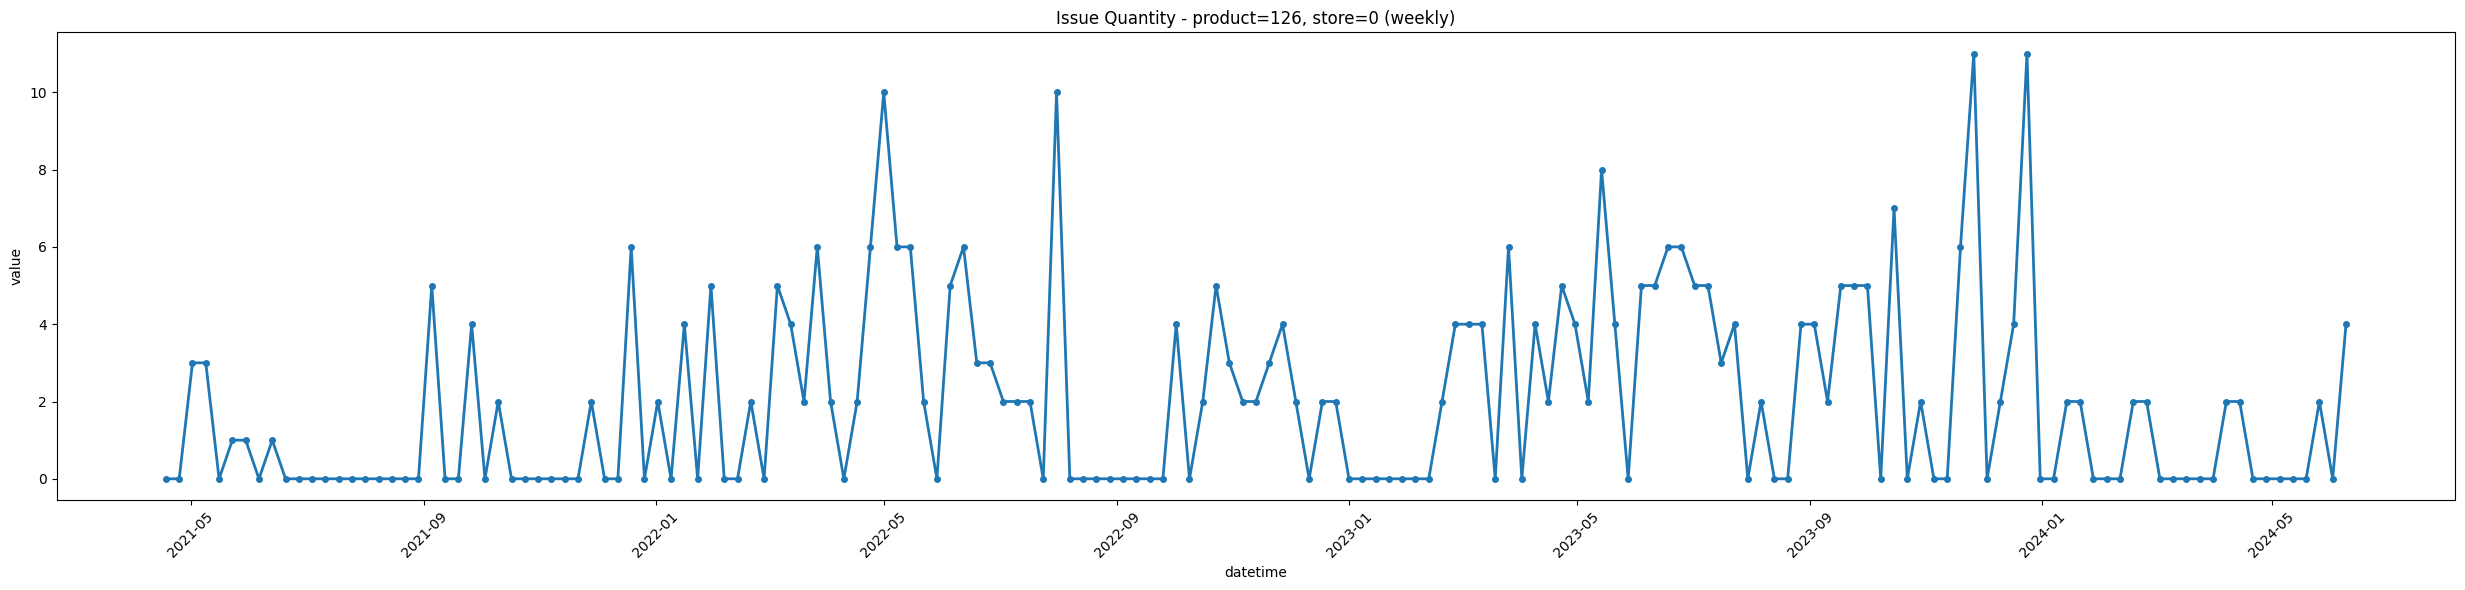

In [37]:
plot_issue_quantity_line(product='126', store='0', aggregation='weekly')

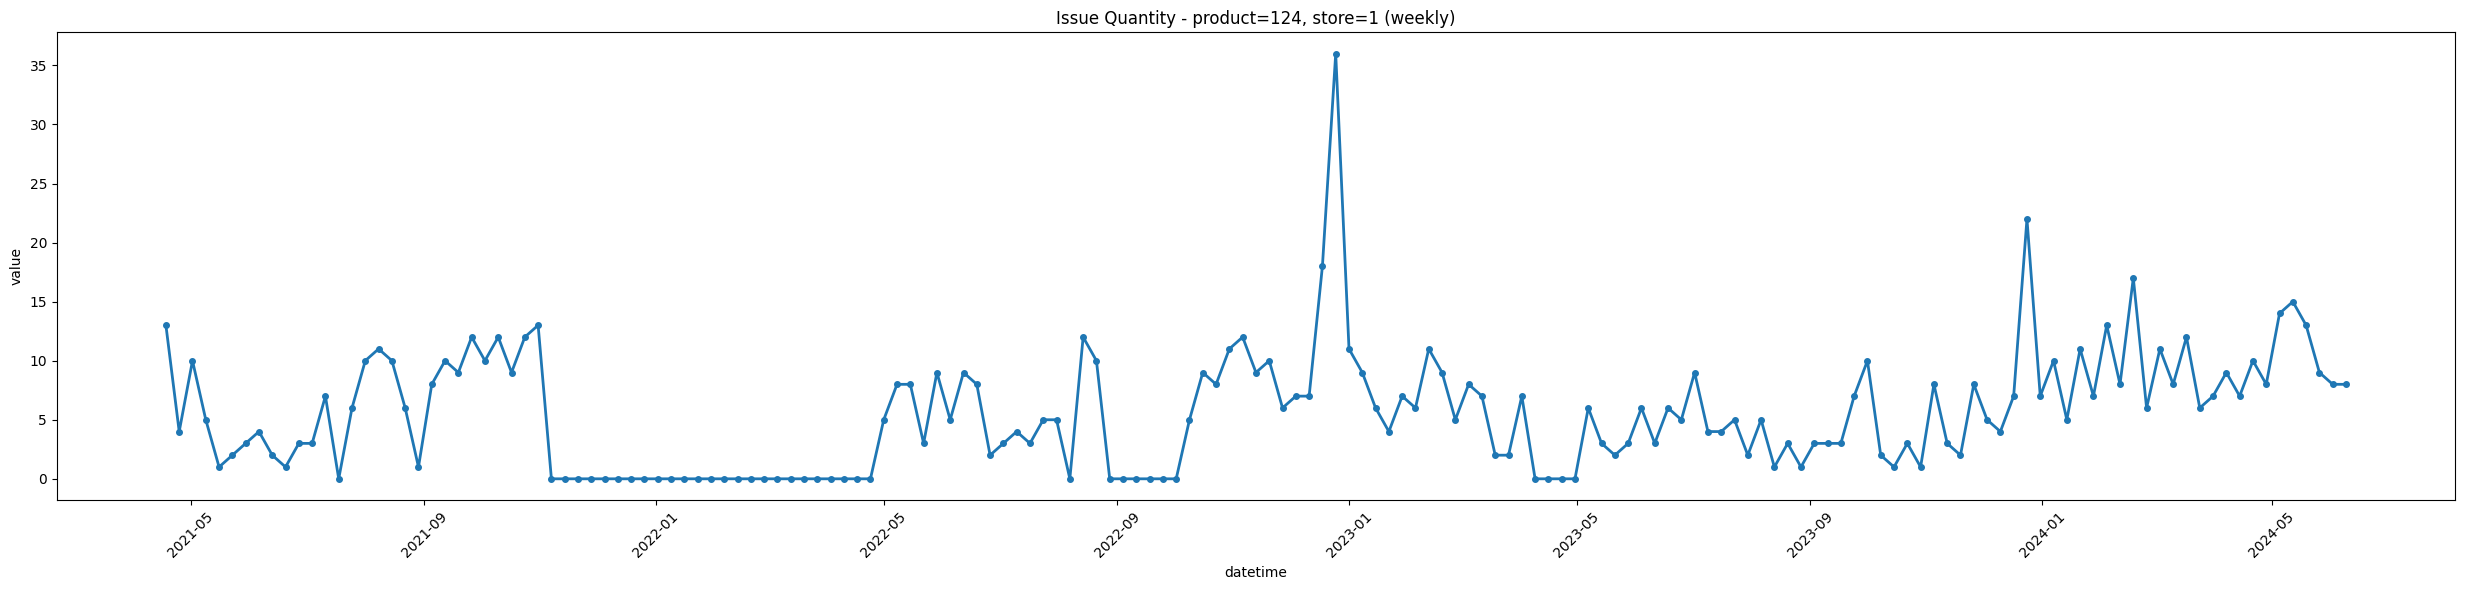

In [38]:
plot_issue_quantity_line(product='124', store='1', aggregation='weekly')

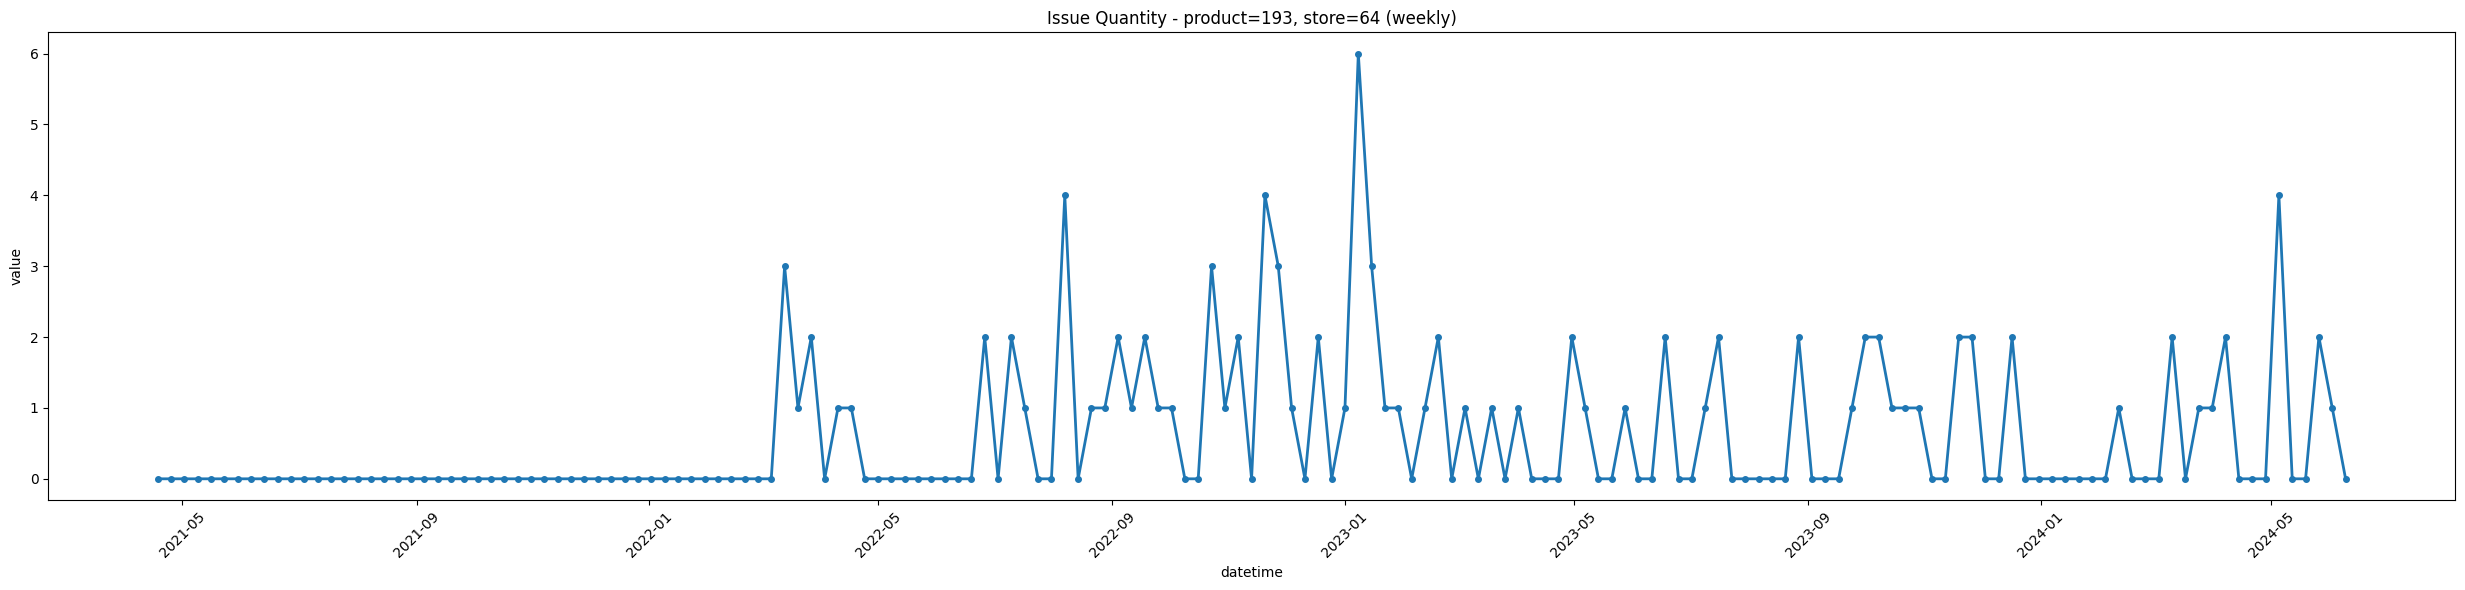

In [39]:
plot_issue_quantity_line(product='193', store='64', aggregation='weekly')

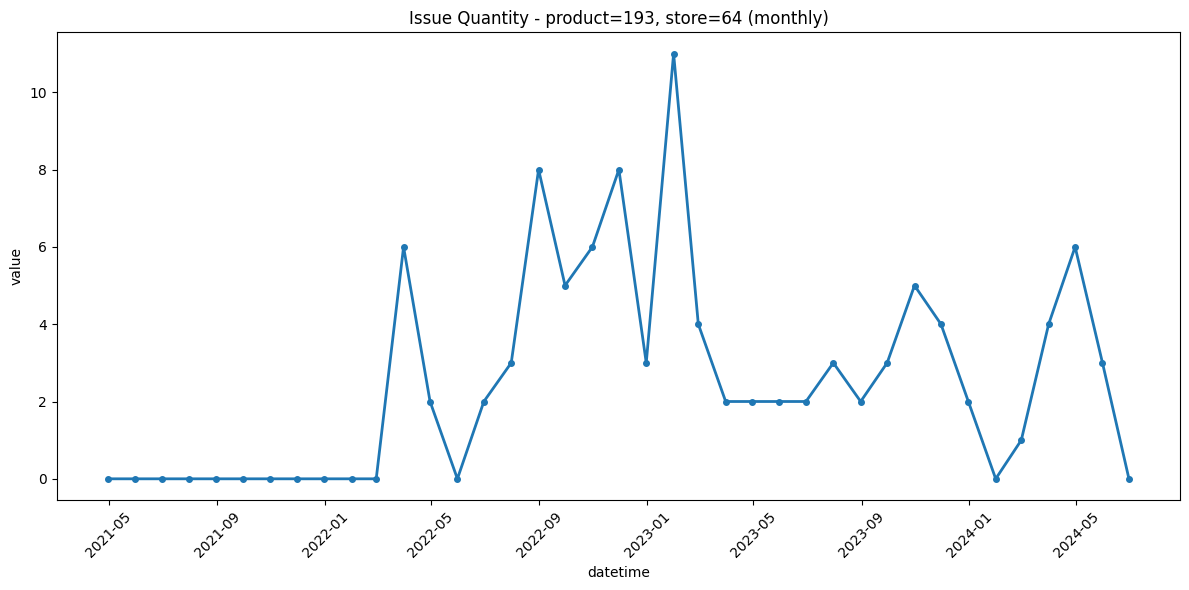

In [40]:
plot_issue_quantity_line(product='193', store='64', aggregation='monthly')

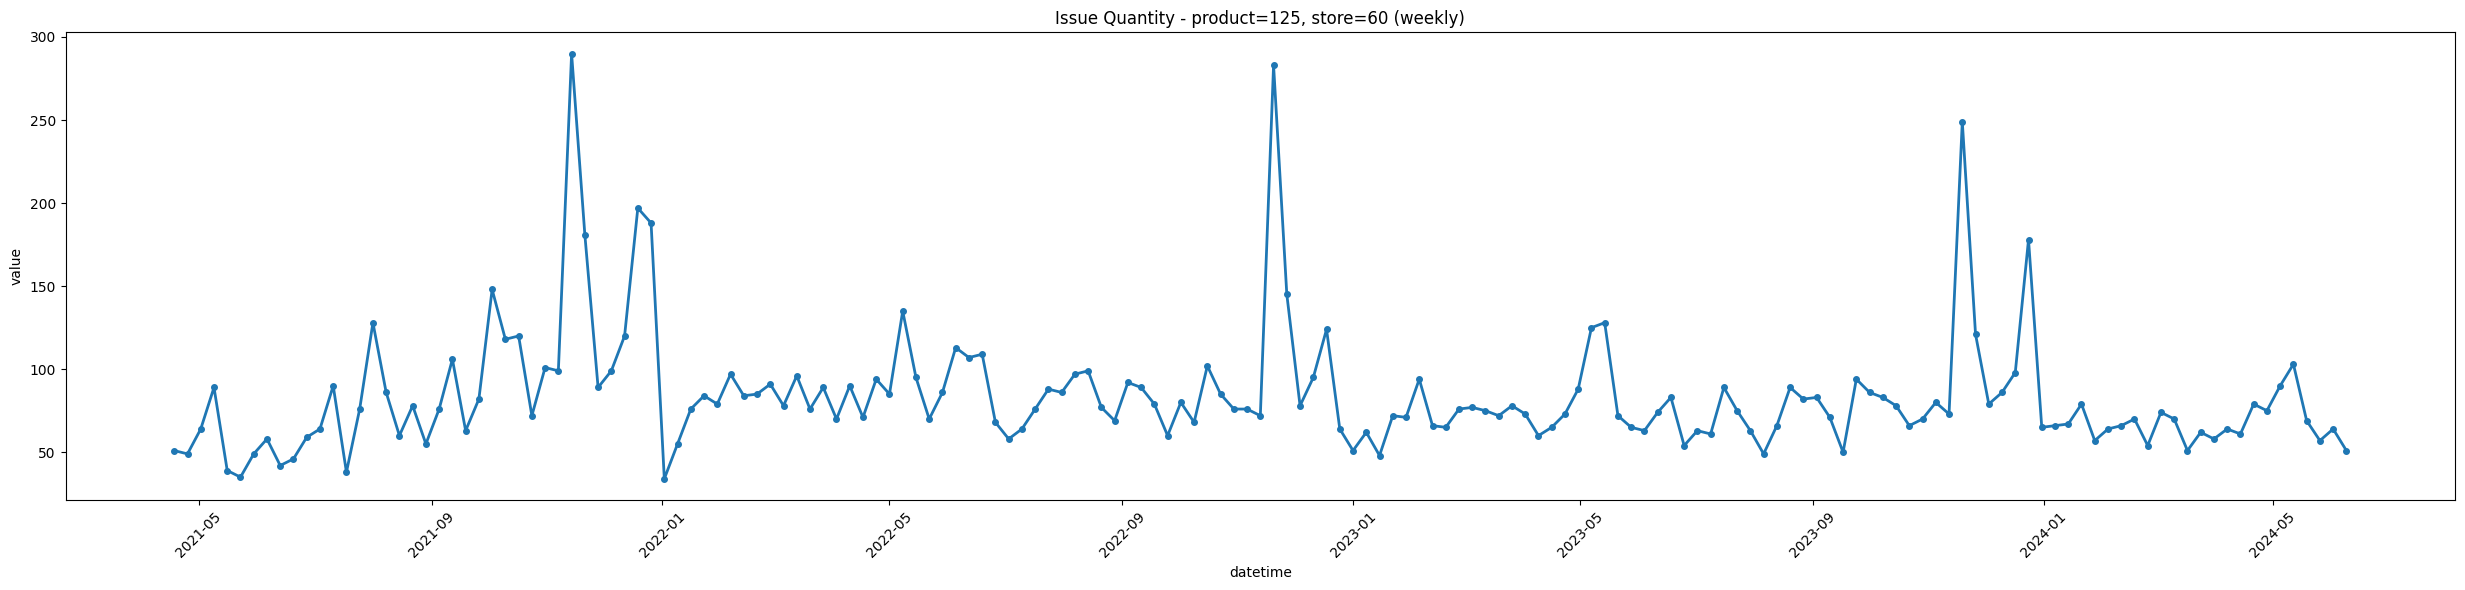

In [41]:
plot_issue_quantity_line(product='125', store='60', aggregation='weekly')